# Human Meninges Loom Scaffold

This notebook uses only the loom files under `xenium_meningioma`.

It reads every `*.loom` file with `sc.read_loom`, standardizes the per-file metadata, concatenates them into one combined cell-level `AnnData`, and saves the combined object plus summary tables.


## 1) Imports and environment defaults


In [1]:
import os
import warnings
from pathlib import Path

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

warnings.filterwarnings("ignore")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from scipy.sparse import csr_matrix, issparse

ad.settings.allow_write_nullable_strings = True
sc.settings.verbosity = 2
sc.set_figure_params(dpi=110, facecolor="white")


## 2) Configure input and output paths


In [2]:
DATASET_NAME = "humanDevMeninges"
LOOM_DIR = Path("/Users/chrislangseth/Downloads/xenium_dev_meninges/")
OUTPUT_DIR = Path("/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/humanDevMeninges")

COMBINED_H5AD_PATH = OUTPUT_DIR / f"{DATASET_NAME}_loom_celllevel_combined.h5ad"
OBS_PATH = OUTPUT_DIR / f"{DATASET_NAME}_loom_obs.csv.gz"
VAR_PATH = OUTPUT_DIR / f"{DATASET_NAME}_loom_var.csv.gz"
SAMPLE_SUMMARY_PATH = OUTPUT_DIR / f"{DATASET_NAME}_loom_sample_summary.csv"

print("LOOM_DIR:", LOOM_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


LOOM_DIR: /Users/chrislangseth/Downloads/xenium_dev_meninges
OUTPUT_DIR: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/humanDevMeninges


## 3) Confirm the input directory and inspect the files


In [3]:
if not LOOM_DIR.exists():
    raise FileNotFoundError(f"Could not find: {LOOM_DIR}")

LOOM_PATHS = sorted(LOOM_DIR.glob("*.loom"))
if not LOOM_PATHS:
    raise FileNotFoundError(f"No loom files found under: {LOOM_DIR}")

loom_file_table = pd.DataFrame(
    {
        "loom_file": [p.name for p in LOOM_PATHS],
        "size_gb": [round(p.stat().st_size / 1024**3, 3) for p in LOOM_PATHS],
    }
)

loom_file_table


,loom_file,size_gb
0,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,2.357
1,HumanMeningesDev_Xenium_pcw9_final_clusters_EE...,7.254


## 4) Helper functions


In [4]:
def ensure_csr_layers(adata: ad.AnnData) -> None:
    if issparse(adata.X) and not isinstance(adata.X, csr_matrix):
        adata.X = adata.X.tocsr()

    for key, layer in list(adata.layers.items()):
        if issparse(layer) and not isinstance(layer, csr_matrix):
            adata.layers[key] = layer.tocsr()


def matrix_is_integer_like(matrix, n_values: int = 100000) -> bool:
    values = matrix.data if issparse(matrix) else np.asarray(matrix).ravel()
    if values.size == 0:
        return True

    sample = values[: min(values.size, n_values)]
    return bool(np.allclose(sample, np.round(sample)))


def read_single_celllevel_loom(loom_path: Path) -> ad.AnnData:
    adata = sc.read_loom(str(loom_path))
    adata.obs_names = adata.obs_names.astype(str)
    adata.var_names = adata.var_names.astype(str)
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    ensure_csr_layers(adata)

    sample_id = loom_path.stem.replace("Xenium_meningioma_", "")
    adata.obs["sample_id"] = sample_id
    adata.obs["loom_file"] = loom_path.name
    adata.obs_names = sample_id + "__" + adata.obs_names.astype(str)

    if "cell_id" not in adata.obs.columns:
        adata.obs["cell_id"] = adata.obs_names.astype(str)

    if {"x_centroid", "y_centroid"}.issubset(adata.obs.columns):
        adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].to_numpy()

    if "UMAP" in adata.obsm:
        adata.obsm["X_umap"] = np.asarray(adata.obsm["UMAP"]).copy()

    adata.uns["source_loom"] = str(loom_path)
    adata.uns["x_matrix_integer_like"] = matrix_is_integer_like(adata.X)
    if "raw" in adata.layers:
        adata.uns["raw_layer_integer_like"] = matrix_is_integer_like(adata.layers["raw"])

    return adata


def read_celllevel_loom_dir(loom_dir: Path):
    loom_paths = sorted(loom_dir.glob("*.loom"))
    if not loom_paths:
        raise FileNotFoundError(f"No loom files found under: {loom_dir}")

    adatas = []
    sample_rows = []
    for loom_path in loom_paths:
        adata = read_single_celllevel_loom(loom_path)
        sample_rows.append(
            {
                "sample_id": adata.obs["sample_id"].iloc[0],
                "loom_file": loom_path.name,
                "n_cells": adata.n_obs,
                "n_genes": adata.n_vars,
                "has_raw_layer": "raw" in adata.layers,
                "x_matrix_integer_like": adata.uns.get("x_matrix_integer_like"),
                "raw_layer_integer_like": adata.uns.get("raw_layer_integer_like"),
            }
        )
        adatas.append(adata)

    combined = ad.concat(adatas, join="inner", merge="first", index_unique=None)
    ensure_csr_layers(combined)
    combined.uns["source_loom_dir"] = str(loom_dir)
    combined.uns["loom_files"] = [p.name for p in loom_paths]
    combined.uns["x_matrix_integer_like"] = matrix_is_integer_like(combined.X)
    if "raw" in combined.layers:
        combined.uns["raw_layer_integer_like"] = matrix_is_integer_like(combined.layers["raw"])

    sample_summary = pd.DataFrame(sample_rows).sort_values("sample_id").reset_index(drop=True)
    return combined, sample_summary


## 5) Load and concatenate all loom files


In [5]:
adata, sample_summary = read_celllevel_loom_dir(LOOM_DIR)

print(adata)
display(sample_summary)
adata.obs[[c for c in ["sample_id", "loom_file", "cell_id", "x_centroid", "y_centroid", "transcript_counts", "n_genes", "10x_celltype", "leiden_1_0"] if c in adata.obs.columns]].head()


AnnData object with n_obs × n_vars = 780083 × 389
    obs: '10x_cluster', 'CellTypes', 'Clusters', 'X', 'X_umap', 'Y', 'Y_umap', 'cell_area', 'cell_id', 'cell_type_E', 'control_codeword_counts', 'control_probe_counts', 'leiden_2_0', 'n_counts', 'n_genes', 'nucleus_area', 'replicate', 'total_counts', 'transcript_counts', 'unassigned_codeword_counts', 'x_centroid', 'y_centroid', 'sample_id', 'loom_file'
    var: 'Accession', 'dispersions', 'dispersions_norm', 'feature_name', 'highly_variable', 'means'
    uns: 'source_loom_dir', 'loom_files', 'x_matrix_integer_like', 'raw_layer_integer_like'
    obsm: 'TP_35_Recombined3Clean2_C_FBPC', 'UMAP', 'spatial', 'X_umap'
    layers: 'raw'


,sample_id,loom_file,n_cells,n_genes,has_raw_layer,x_matrix_integer_like,raw_layer_integer_like
0,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,271679,389,True,False,False
1,HumanMeningesDev_Xenium_pcw9_final_clusters_EE...,HumanMeningesDev_Xenium_pcw9_final_clusters_EE...,508404,389,True,False,False


,sample_id,loom_file,cell_id,x_centroid,y_centroid,transcript_counts,n_genes
CellID,,,,,,,
HumanMeningesDev_Xenium_pcw6_final_clusters_EE_dev_HE27__aaaabljk-1_dev_HE27a,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,aaaabljk-1,824.288071,6805.946265,167,60
HumanMeningesDev_Xenium_pcw6_final_clusters_EE_dev_HE27__aaaadhll-1_dev_HE27a,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,aaaadhll-1,839.043488,6803.062573,202,48
HumanMeningesDev_Xenium_pcw6_final_clusters_EE_dev_HE27__aaaaiade-1_dev_HE27a,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,aaaaiade-1,843.415250,6810.334473,89,46
HumanMeningesDev_Xenium_pcw6_final_clusters_EE_dev_HE27__aaaaodnc-1_dev_HE27a,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,aaaaodnc-1,833.121658,6817.080518,171,73
HumanMeningesDev_Xenium_pcw6_final_clusters_EE_dev_HE27__aaaapbjl-1_dev_HE27a,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,aaaapbjl-1,839.205405,6822.293408,174,61


## 6) Inspect the combined object


In [6]:
print(adata)
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))
print("layers:", list(adata.layers.keys()))
print("obsm:", list(adata.obsm.keys()))
print("n_samples:", adata.obs["sample_id"].nunique())


AnnData object with n_obs × n_vars = 780083 × 389
    obs: '10x_cluster', 'CellTypes', 'Clusters', 'X', 'X_umap', 'Y', 'Y_umap', 'cell_area', 'cell_id', 'cell_type_E', 'control_codeword_counts', 'control_probe_counts', 'leiden_2_0', 'n_counts', 'n_genes', 'nucleus_area', 'replicate', 'total_counts', 'transcript_counts', 'unassigned_codeword_counts', 'x_centroid', 'y_centroid', 'sample_id', 'loom_file'
    var: 'Accession', 'dispersions', 'dispersions_norm', 'feature_name', 'highly_variable', 'means'
    uns: 'source_loom_dir', 'loom_files', 'x_matrix_integer_like', 'raw_layer_integer_like'
    obsm: 'TP_35_Recombined3Clean2_C_FBPC', 'UMAP', 'spatial', 'X_umap'
    layers: 'raw'
obs columns: ['10x_cluster', 'CellTypes', 'Clusters', 'X', 'X_umap', 'Y', 'Y_umap', 'cell_area', 'cell_id', 'cell_type_E', 'control_codeword_counts', 'control_probe_counts', 'leiden_2_0', 'n_counts', 'n_genes', 'nucleus_area', 'replicate', 'total_counts', 'transcript_counts', 'unassigned_codeword_counts', 'x_cen

## 7) Combined loom summary


In [7]:
loom_summary = pd.Series(
    {
        "loom_n_files": len(adata.uns.get("loom_files", [])),
        "combined_x_matrix_integer_like": adata.uns.get("x_matrix_integer_like"),
        "combined_raw_layer_integer_like": adata.uns.get("raw_layer_integer_like"),
        "has_spatial": "spatial" in adata.obsm,
        "has_vendor_umap": "X_umap" in adata.obsm,
        "n_cells": adata.n_obs,
        "n_genes": adata.n_vars,
        "n_samples": adata.obs["sample_id"].nunique(),
    }
)

display(loom_summary)
display(sample_summary)


loom_n_files                            2
combined_x_matrix_integer_like      False
combined_raw_layer_integer_like     False
has_spatial                          True
has_vendor_umap                      True
n_cells                            780083
n_genes                               389
n_samples                               2
dtype: object

,sample_id,loom_file,n_cells,n_genes,has_raw_layer,x_matrix_integer_like,raw_layer_integer_like
0,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,HumanMeningesDev_Xenium_pcw6_final_clusters_EE...,271679,389,True,False,False
1,HumanMeningesDev_Xenium_pcw9_final_clusters_EE...,HumanMeningesDev_Xenium_pcw9_final_clusters_EE...,508404,389,True,False,False


## 8) Quick spatial and vendor UMAP inspection


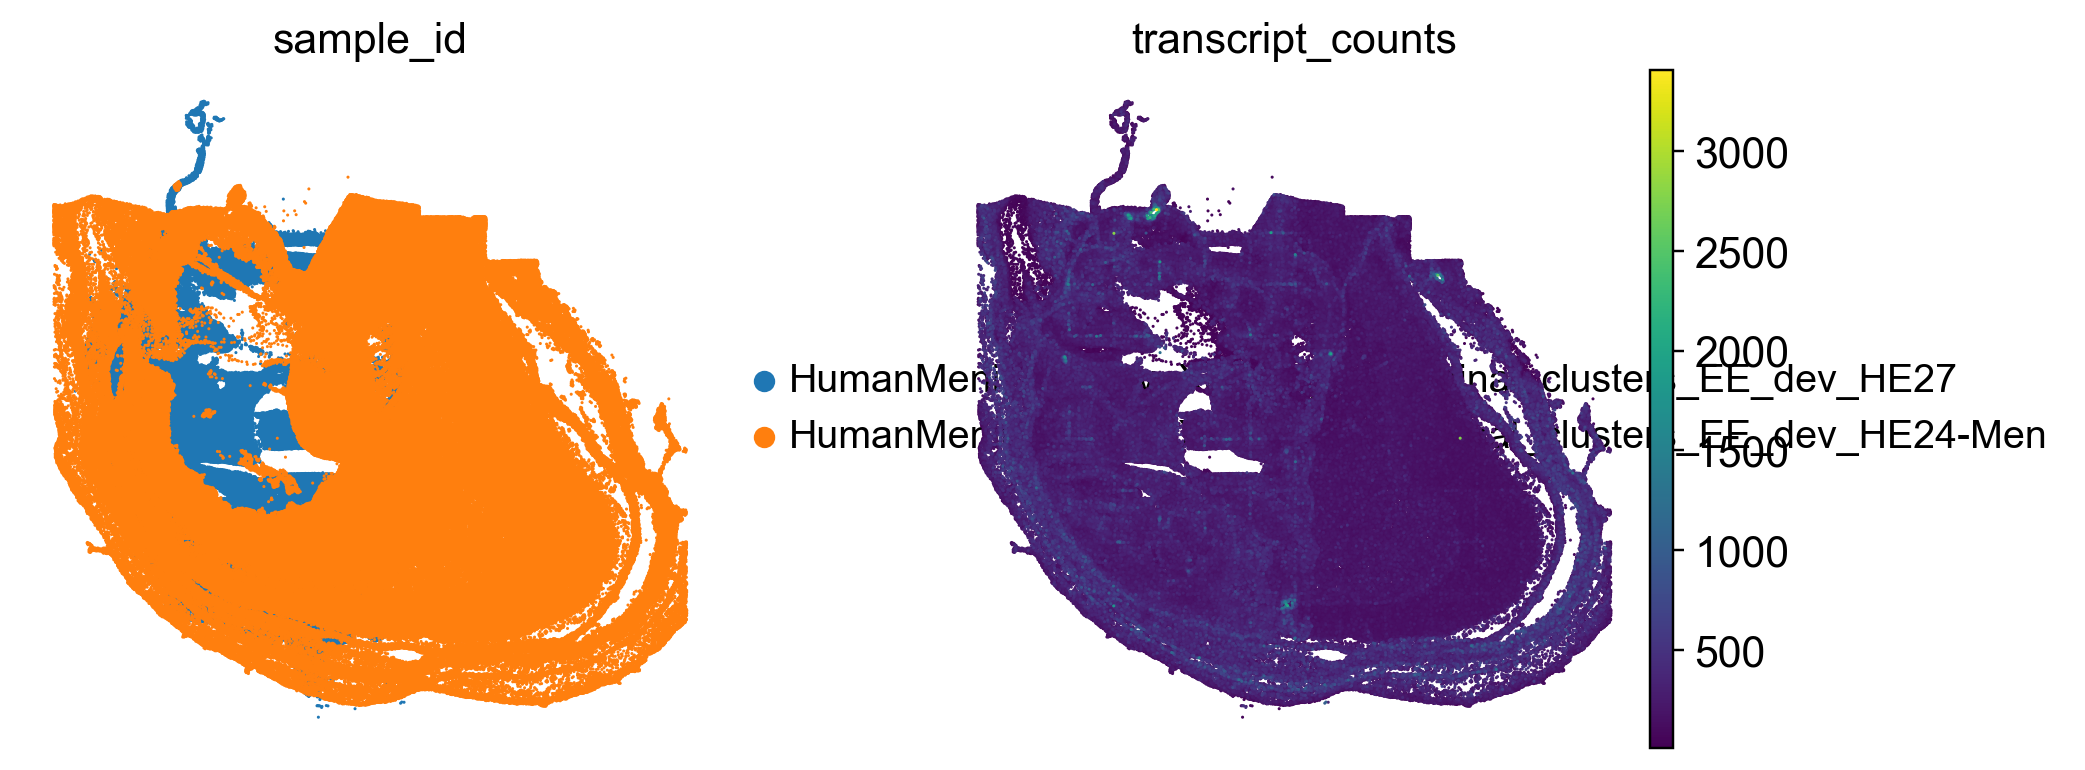

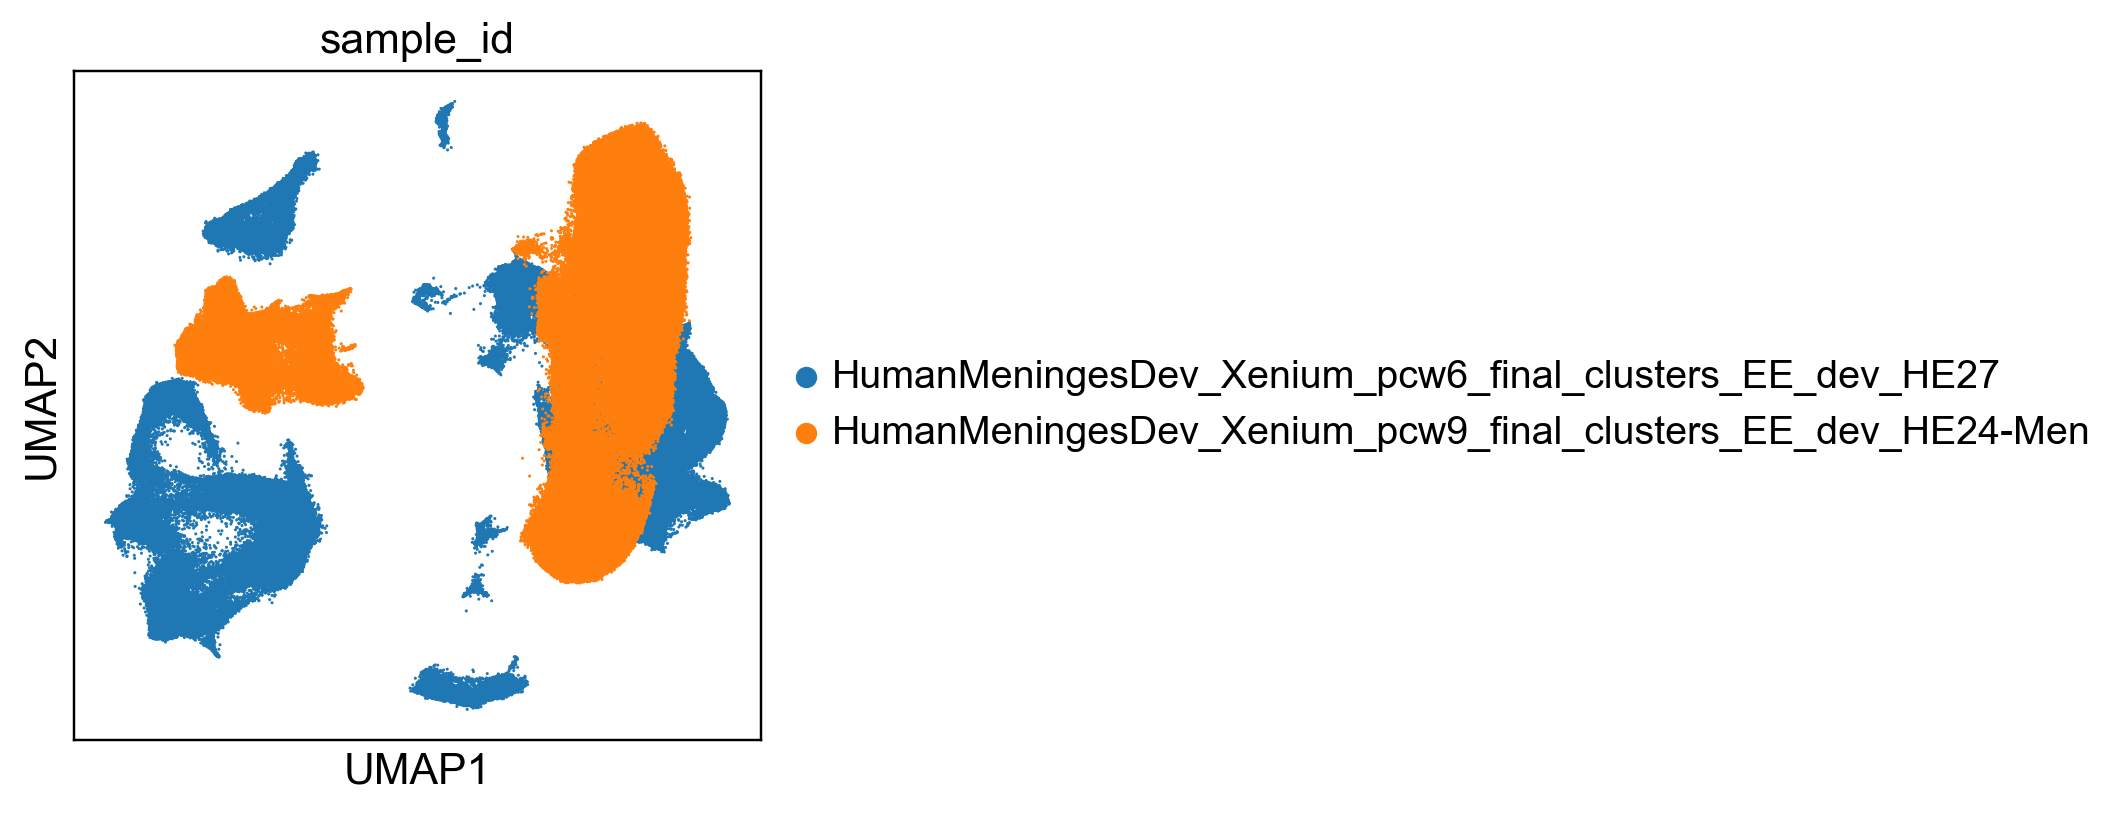

In [8]:
plot_cols = [c for c in ["sample_id", "transcript_counts", "n_genes", "10x_celltype", "leiden_1_0"] if c in adata.obs.columns]

if plot_cols and "spatial" in adata.obsm:
    sc.pl.embedding(
        adata,
        basis="spatial",
        color=plot_cols[:2],
        s=4,
        frameon=False,
    )

if "X_umap" in adata.obsm:
    sc.pl.umap(adata, color=[c for c in ["sample_id", "10x_celltype", "leiden_1_0"] if c in adata.obs.columns][:2], s=4)


## 9) Per-sample summaries from the combined loom object


In [9]:
sample_qc = (
    adata.obs.groupby("sample_id")
    .agg(
        n_cells=("cell_id", "count"),
        mean_transcript_counts=("transcript_counts", "mean"),
        median_transcript_counts=("transcript_counts", "median"),
        mean_n_genes=("n_genes", "mean"),
        median_n_genes=("n_genes", "median"),
    )
    .sort_values("n_cells", ascending=False)
)

sample_qc


,n_cells,mean_transcript_counts,median_transcript_counts,mean_n_genes,median_n_genes
sample_id,,,,,
HumanMeningesDev_Xenium_pcw9_final_clusters_EE_dev_HE24-Men,508404,116.416179,96.0,37.436204,37.0
HumanMeningesDev_Xenium_pcw6_final_clusters_EE_dev_HE27,271679,134.913214,120.0,45.102897,45.0


## 10) Write extraction outputs

These are the main artifacts to keep for the loom-only workflow.


In [10]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

adata.write_h5ad(COMBINED_H5AD_PATH)
adata.obs.to_csv(OBS_PATH, index=True)
adata.var.to_csv(VAR_PATH, index=True)
sample_summary.to_csv(SAMPLE_SUMMARY_PATH, index=False)

print(f"Wrote: {COMBINED_H5AD_PATH}")
print(f"Wrote: {OBS_PATH}")
print(f"Wrote: {VAR_PATH}")
print(f"Wrote: {SAMPLE_SUMMARY_PATH}")


Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/humanDevMeninges/humanDevMeninges_loom_celllevel_combined.h5ad
Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/humanDevMeninges/humanDevMeninges_loom_obs.csv.gz
Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/humanDevMeninges/humanDevMeninges_loom_var.csv.gz
Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/humanDevMeninges/humanDevMeninges_loom_sample_summary.csv


## 11) Notes

The combined loom object already looks vendor-processed rather than raw integer-count data. That means it is best treated as a cell-level reference / analysis object unless you confirm that a true raw-count layer exists for the downstream method you want to run.


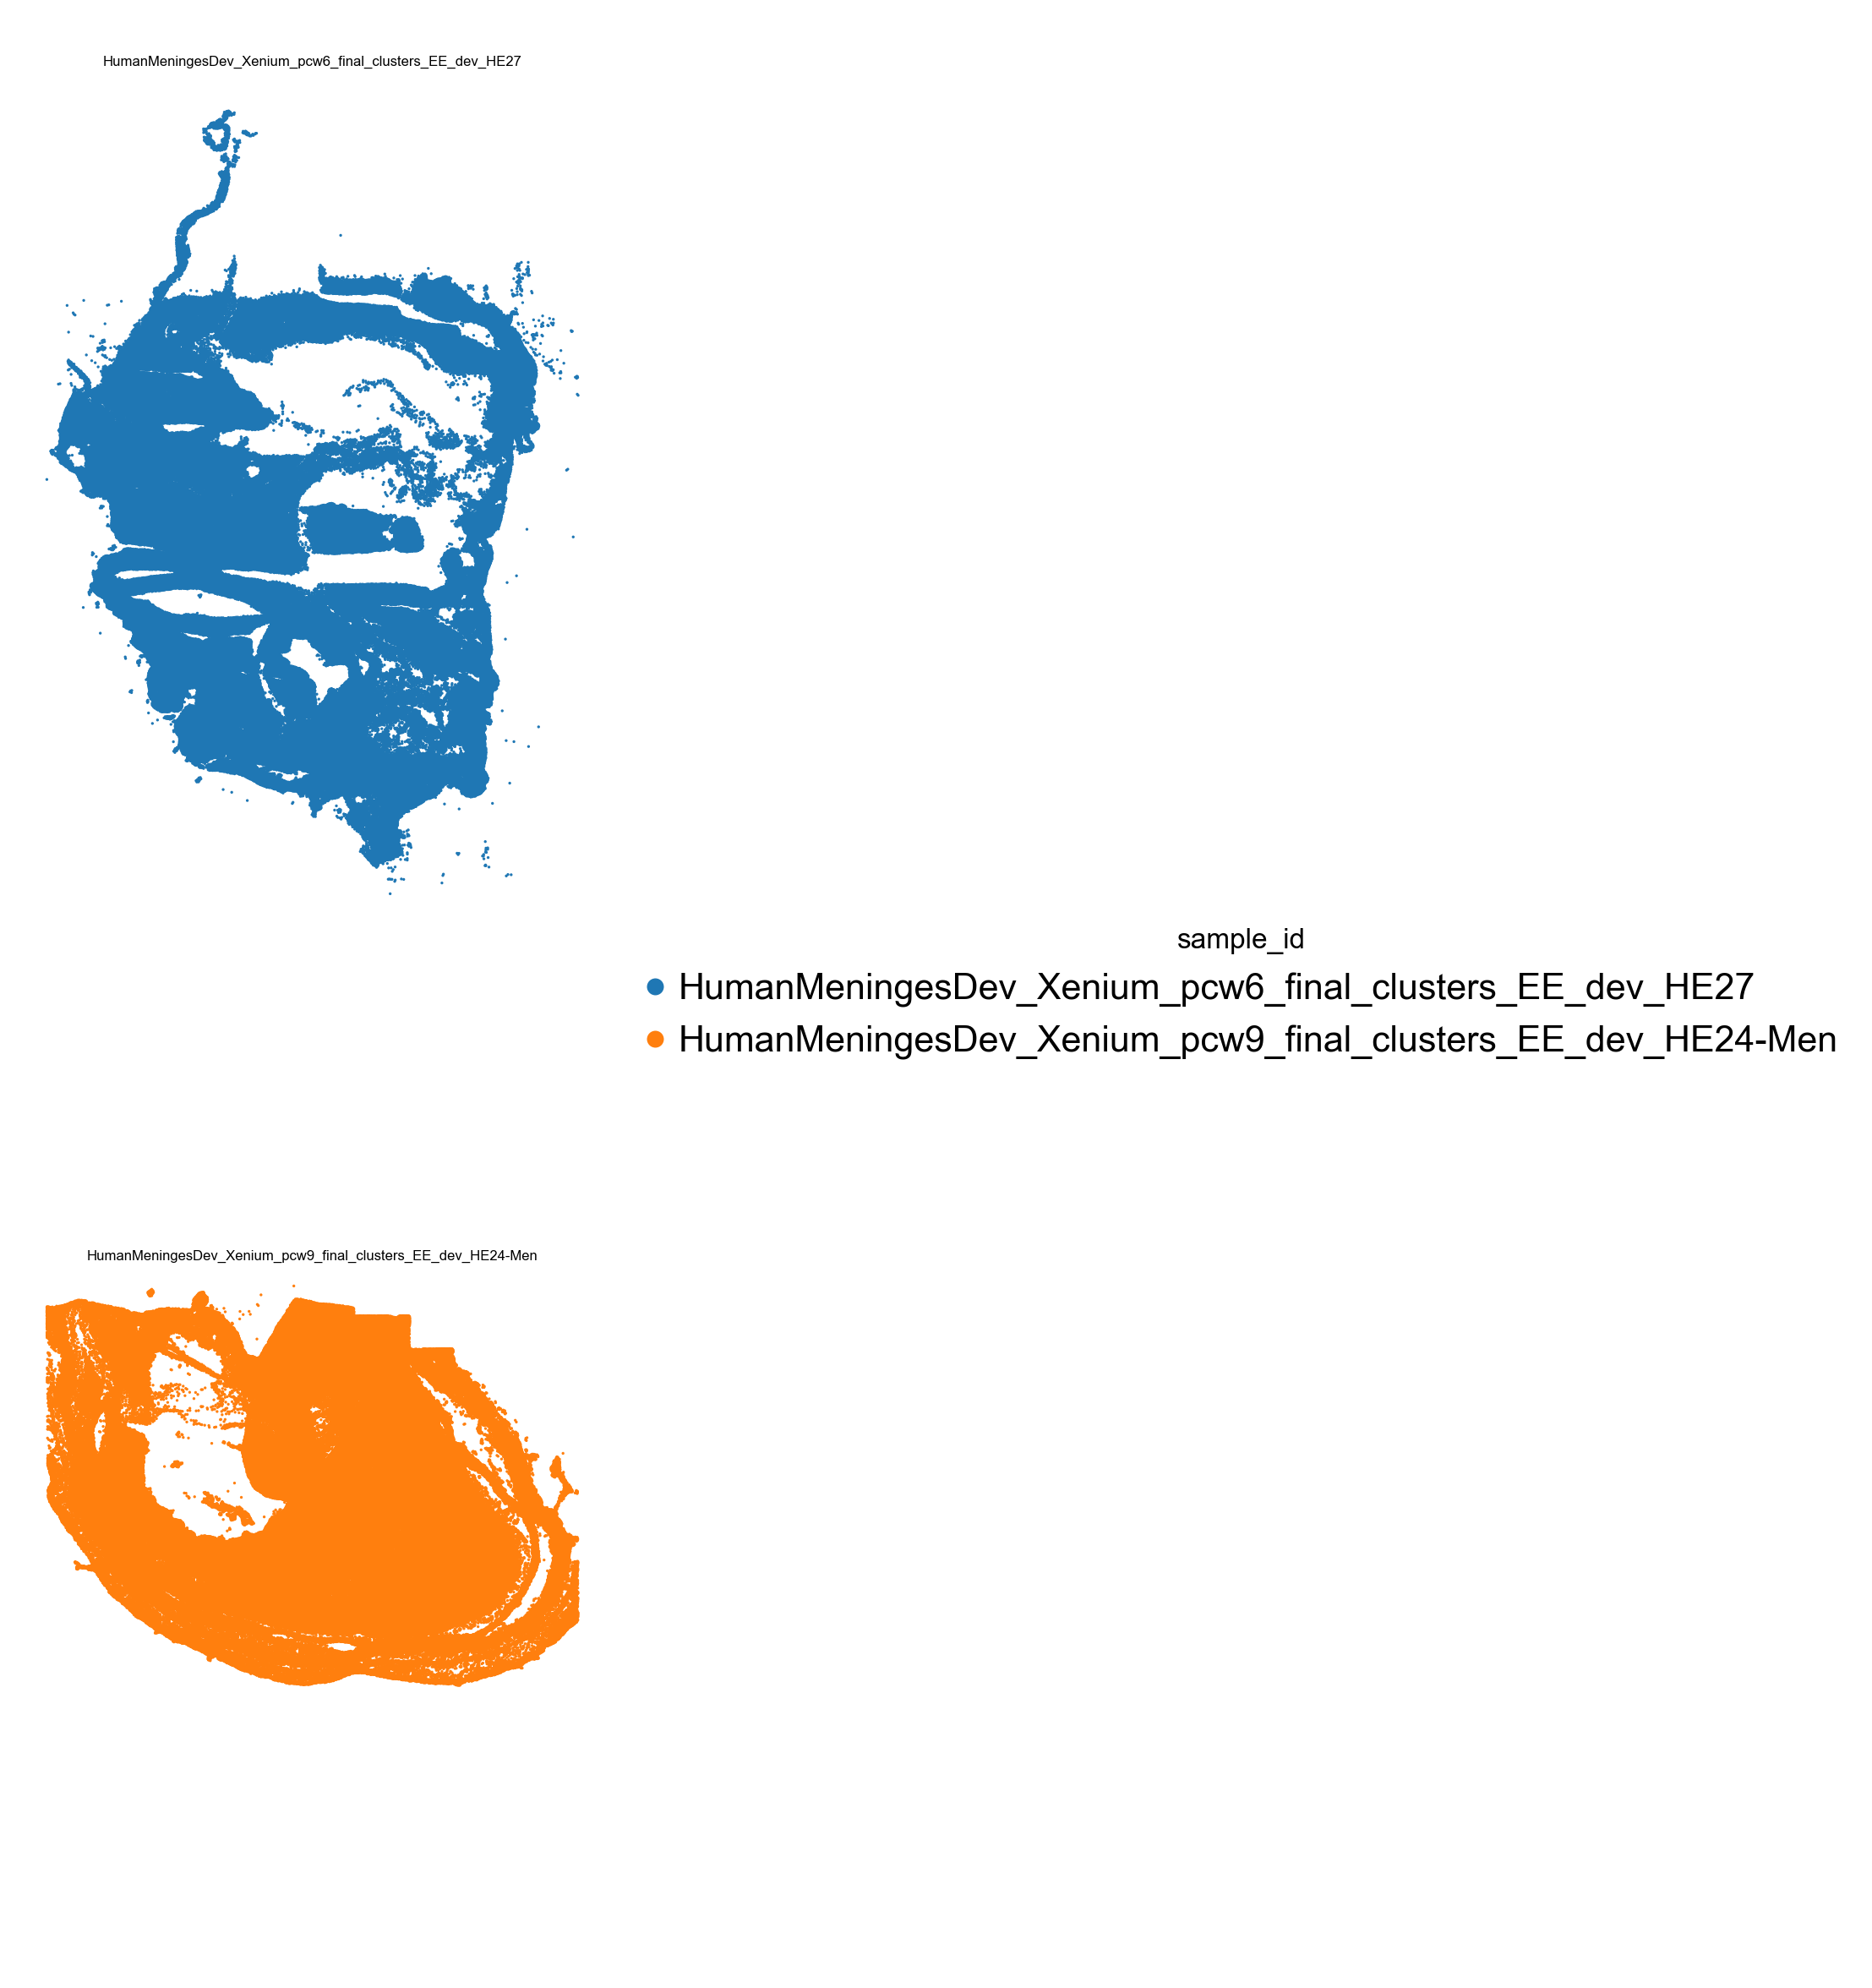

In [11]:
import sys
sys.path.append("/Users/chrislangseth/work/karolinska_institutet/projects/BaloMS/")
from utils import spatial_utils

spatial_utils.plot_spatial_compact_fast(
    adata,
    color="sample_id",
    groupby="sample_id",
    spot_size=1,
    cols=1,
    height=10,
    background="white",
    dpi=120,
)


In [12]:
import squidpy as sq
import cellcharter as cc

In [13]:
adata.obs['sample_id'] = adata.obs['sample_id'].astype('category')

In [14]:
sq.gr.spatial_neighbors(adata, library_key='sample_id', coord_type='generic', delaunay=True, percentile=99)


Creating graph using `generic` coordinates and `None` transform and `2` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:01:45)


In [15]:
import scvi


In [19]:
adata

AnnData object with n_obs × n_vars = 780083 × 389
    obs: '10x_cluster', 'CellTypes', 'Clusters', 'X', 'X_umap', 'Y', 'Y_umap', 'cell_area', 'cell_id', 'cell_type_E', 'control_codeword_counts', 'control_probe_counts', 'leiden_2_0', 'n_counts', 'n_genes', 'nucleus_area', 'replicate', 'total_counts', 'transcript_counts', 'unassigned_codeword_counts', 'x_centroid', 'y_centroid', 'sample_id', 'loom_file'
    var: 'Accession', 'dispersions', 'dispersions_norm', 'feature_name', 'highly_variable', 'means'
    uns: 'source_loom_dir', 'loom_files', 'x_matrix_integer_like', 'raw_layer_integer_like', 'sample_id_colors', 'spatial_neighbors'
    obsm: 'TP_35_Recombined3Clean2_C_FBPC', 'UMAP', 'spatial', 'X_umap'
    layers: 'raw'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [21]:
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="raw", 
    batch_key='sample_id',
)

model = scvi.model.SCVI(adata)

In [22]:
import numpy as np

In [23]:
model.train(early_stopping=True, enable_progress_bar=True, max_epochs = 30 )


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 30/30: 100%|██████████| 30/30 [1:05:09<00:00, 124.53s/it, v_num=1, train_loss=158]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [1:05:09<00:00, 130.33s/it, v_num=1, train_loss=158]


In [24]:
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)

In [25]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key='sample_id')


100%|██████████| 2/2 [00:11<00:00,  5.95s/it]


In [26]:
# GMM components to try
# GMM components to try
gmm_components = [5, 10, 15,20]



In [27]:
from sklearn.mixture import GaussianMixture
import pandas as pd

X = adata.obsm['X_cellcharter']
gmm_results = []

for k in gmm_components:
    print(k)
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=0,
        n_init=3,
    )
    labels = gmm.fit_predict(X)
    key = f'CellCharter_{k}'
    adata.obs[key] = labels.astype(str)
    gmm_results.append({
        'k': k,
        'bic': gmm.bic(X),
        'aic': gmm.aic(X),
    })
    n_clusters = adata.obs[key].nunique()
    print(f'k={k}: {n_clusters} clusters')
    

5
k=5: 5 clusters
10
k=10: 10 clusters
15
k=15: 15 clusters
20
k=20: 20 clusters


In [28]:
import sys
sys.path.append("/Users/chrislangseth/work/karolinska_institutet/projects/BaloMS/")
from utils import spatial_utils

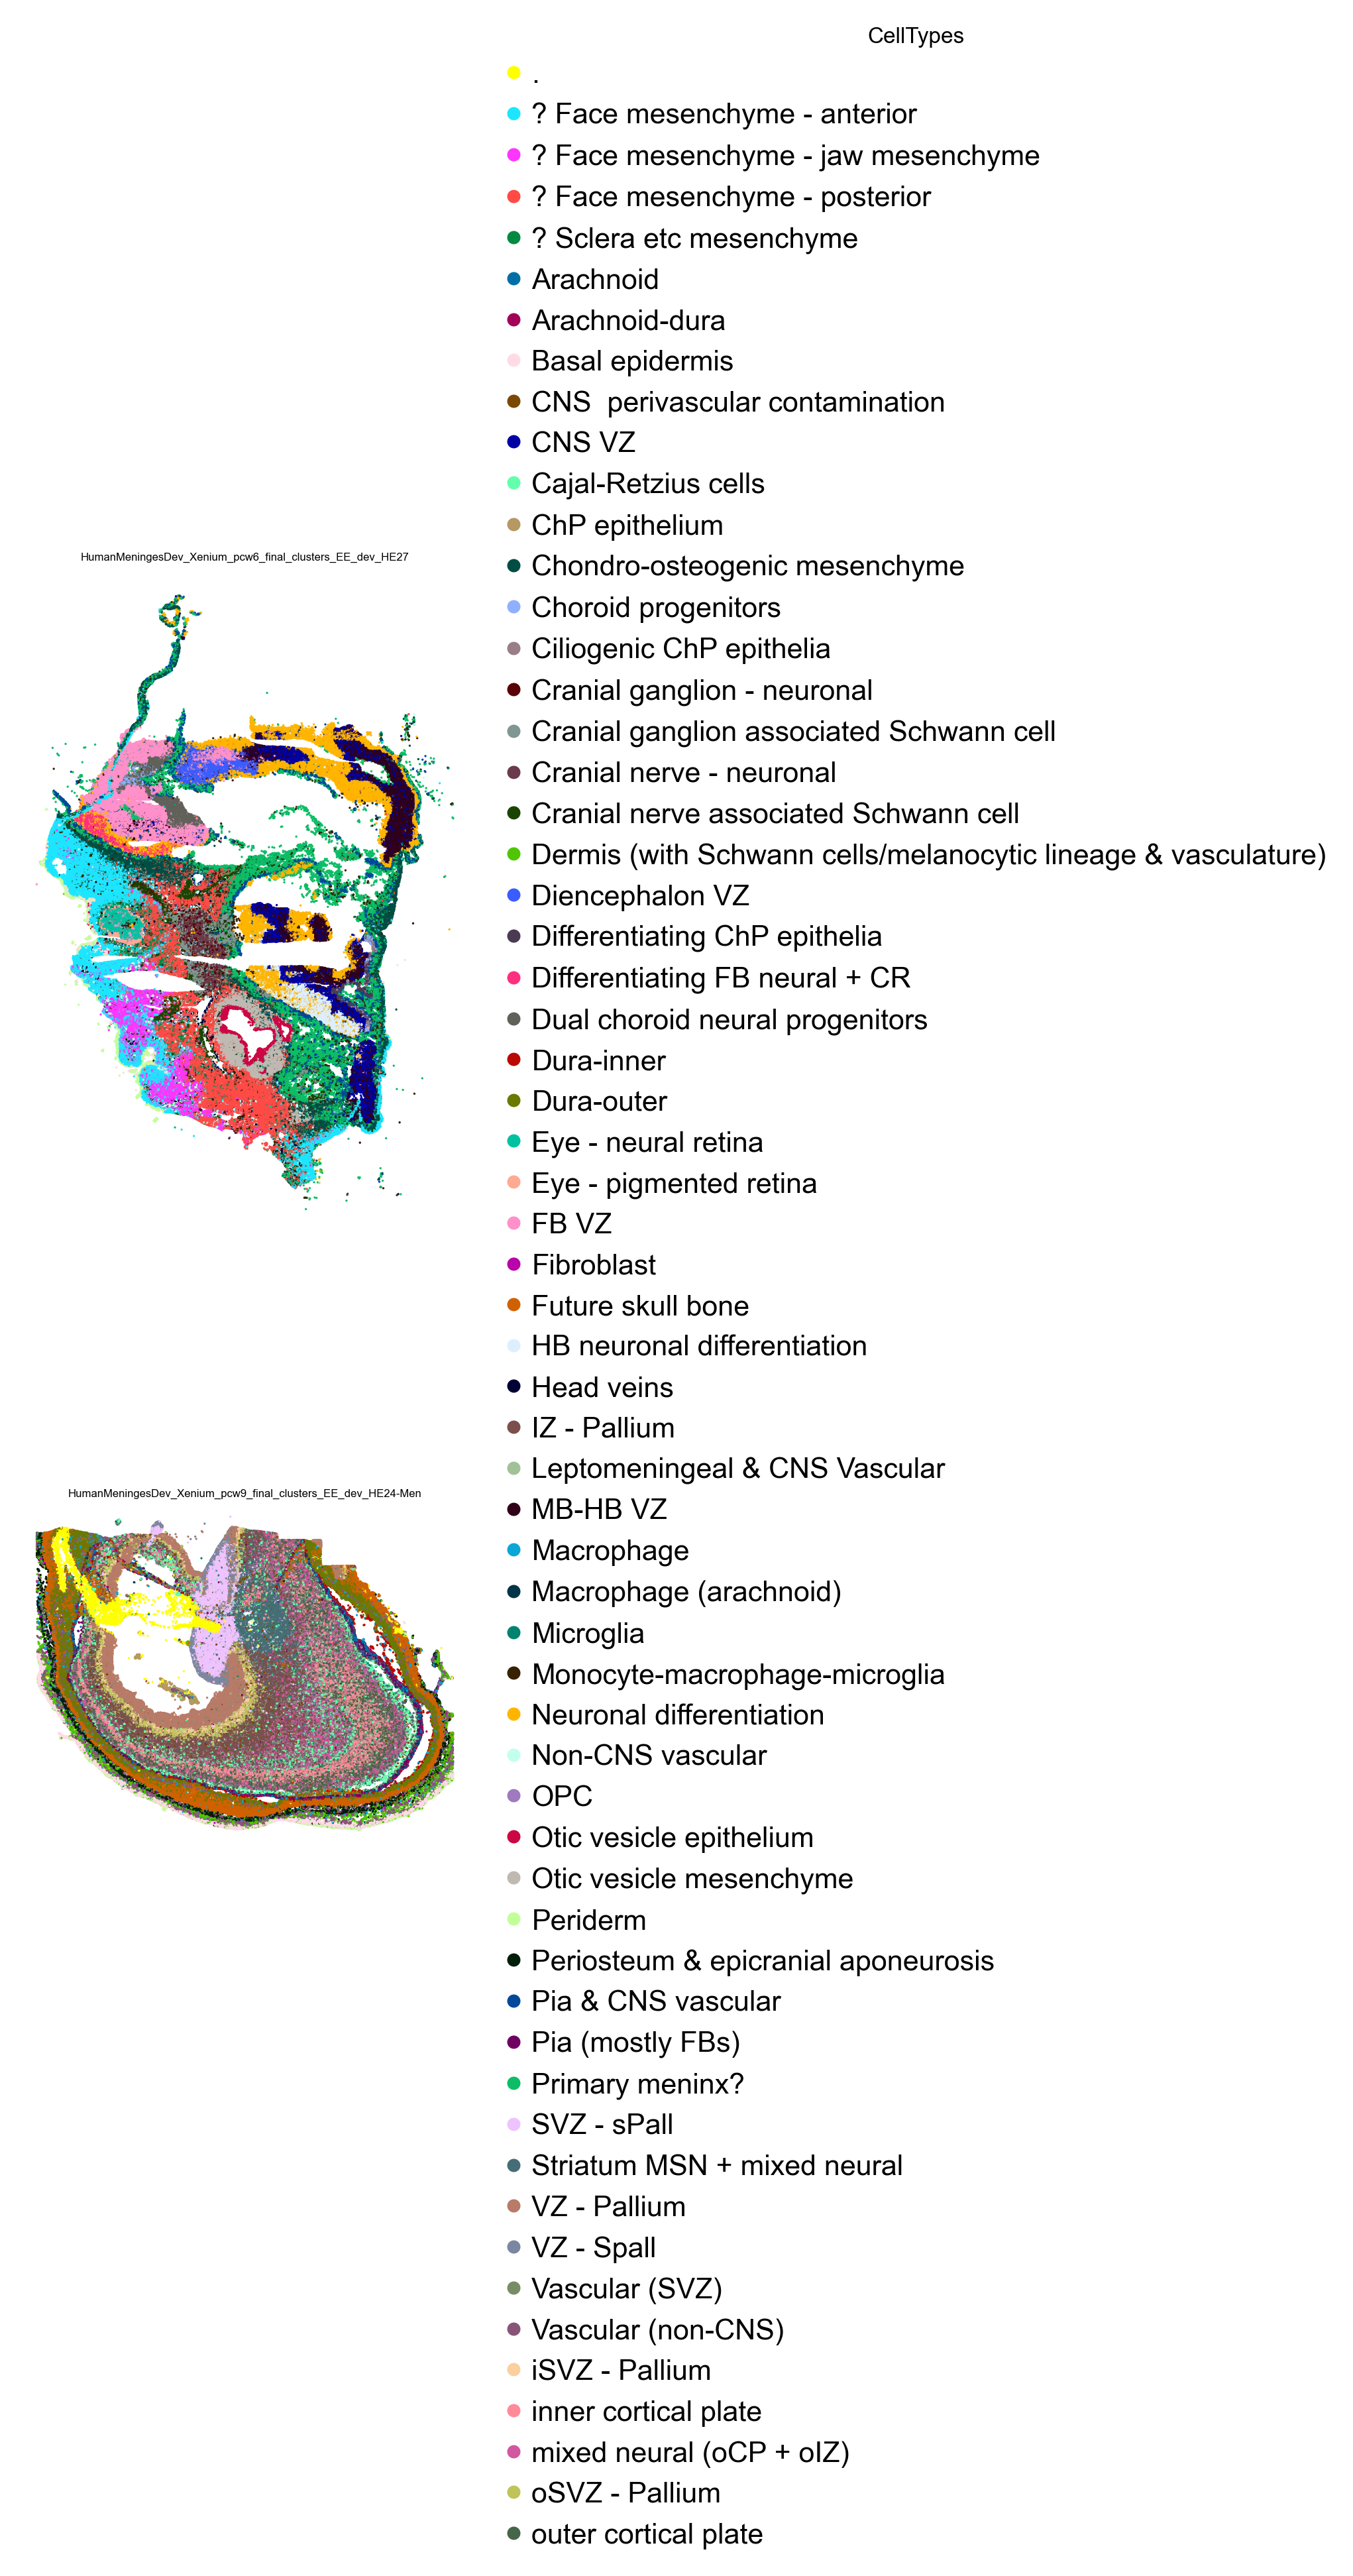

In [38]:
spatial_utils.plot_spatial_compact_fast(
    adata,
    color="CellTypes",
    groupby="sample_id",
    spot_size=1,
    cols=1,
    height=10,
    background="white",
    dpi=120,
)


In [31]:
adata.write_h5ad(COMBINED_H5AD_PATH)


In [32]:
COMBINED_H5AD_PATH

PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/humanDevMeninges/humanDevMeninges_loom_celllevel_combined.h5ad')

In [35]:
adata

AnnData object with n_obs × n_vars = 780083 × 389
    obs: '10x_cluster', 'CellTypes', 'Clusters', 'X', 'X_umap', 'Y', 'Y_umap', 'cell_area', 'cell_id', 'cell_type_E', 'control_codeword_counts', 'control_probe_counts', 'leiden_2_0', 'n_counts', 'n_genes', 'nucleus_area', 'replicate', 'total_counts', 'transcript_counts', 'unassigned_codeword_counts', 'x_centroid', 'y_centroid', 'sample_id', 'loom_file', '_scvi_batch', '_scvi_labels', 'CellCharter_5', 'CellCharter_10', 'CellCharter_15', 'CellCharter_20'
    var: 'Accession', 'dispersions', 'dispersions_norm', 'feature_name', 'highly_variable', 'means'
    uns: 'source_loom_dir', 'loom_files', 'x_matrix_integer_like', 'raw_layer_integer_like', 'sample_id_colors', 'spatial_neighbors', '_scvi_uuid', '_scvi_manager_uuid', 'CellCharter_20_colors', 'CellCharter_10_colors'
    obsm: 'TP_35_Recombined3Clean2_C_FBPC', 'UMAP', 'spatial', 'X_umap', 'X_scVI', 'X_cellcharter'
    layers: 'raw'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [ ]:
sc.tl.pca(ad)
sc.pl.pca_variance_ratio(ad, n_pcs=50, log=True)

sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)